# Supplier Analysis

## Supplier Performance & Procurement Analytics

This notebook evaluates supplier performance using delivery lead time, delivery reliability, lead-time variability, purchase-order activity, and inventory stockout exposure.

The objective is to identify supplier-performance patterns that can support procurement planning, supplier relationship management, inventory policy, and supply-chain risk reduction.

**Workflow:** Processed Data → Supplier Overview → Lead-Time Analysis → Delivery Performance → Lead-Time Variability → Supplier Stockout Exposure → Supplier Risk Analysis → Business Recommendations

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

suppliers = pd.read_csv(
    PROCESSED_DIR / "suppliers_clean.csv"
)

products = pd.read_csv(
    PROCESSED_DIR / "products_clean.csv"
)

inventory = pd.read_csv(
    PROCESSED_DIR / "inventory_clean.csv"
)

purchase_orders = pd.read_csv(
    PROCESSED_DIR / "purchase_orders_clean.csv"
)

inventory["date"] = pd.to_datetime(
    inventory["date"]
)

purchase_orders["order_date"] = pd.to_datetime(
    purchase_orders["order_date"]
)

purchase_orders["expected_date"] = pd.to_datetime(
    purchase_orders["expected_date"]
)

purchase_orders["actual_date"] = pd.to_datetime(
    purchase_orders["actual_date"]
)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data: {PROCESSED_DIR}")

print("\nDataset shapes:")
print(f"Suppliers: {suppliers.shape}")
print(f"Products: {products.shape}")
print(f"Inventory: {inventory.shape}")
print(f"Purchase Orders: {purchase_orders.shape}")

Project root: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis
Processed data: c:\Users\HP 15\Documents\Supply-Chain-Data-Analysis\data\processed

Dataset shapes:
Suppliers: (5, 4)
Products: (20, 7)
Inventory: (7300, 8)
Purchase Orders: (200, 8)


## 2. Supplier Overview

This analysis provides a high-level view of supplier activity across the procurement portfolio.

The analysis measures:

- Number of purchase orders
- Number of products supplied
- Total units ordered
- Total procurement spend

These measures establish the relative procurement exposure associated with each supplier before evaluating delivery performance and supply-chain risk.## 2. Supplier Overview

This analysis provides a high-level view of supplier activity across the procurement portfolio.

The analysis measures:

- Number of purchase orders
- Number of products supplied
- Total units ordered
- Total procurement spend

These measures establish the relative procurement exposure associated with each supplier before evaluating delivery performance and supply-chain risk.

In [2]:
supplier_overview = (
    purchase_orders
    .merge(
        suppliers[
            [
                "supplier_id",
                "supplier_name",
                "category",
                "payment_terms"
            ]
        ],
        on="supplier_id",
        how="left"
    )
)

supplier_overview["procurement_spend"] = (
    supplier_overview["quantity"]
    * supplier_overview["unit_cost"]
)

supplier_summary = (
    supplier_overview
    .groupby(
        [
            "supplier_id",
            "supplier_name",
            "category",
            "payment_terms"
        ],
        as_index=False
    )
    .agg(
        purchase_orders=("po_id", "nunique"),
        products_supplied=("product_id", "nunique"),
        total_units_ordered=("quantity", "sum"),
        procurement_spend=("procurement_spend", "sum")
    )
)

supplier_summary["spend_share"] = (
    supplier_summary["procurement_spend"]
    / supplier_summary["procurement_spend"].sum()
)

supplier_summary = supplier_summary.sort_values(
    "procurement_spend",
    ascending=False
).reset_index(drop=True)

display(supplier_summary)

,supplier_id,supplier_name,category,payment_terms,purchase_orders,products_supplied,total_units_ordered,procurement_spend,spend_share
0,SUP005,Global Industrial Partners,Industrial Equipment,Net 45,39,4,18148,3465645000,0.570567
1,SUP003,Delta Distribution Co,Components,Net 30,59,6,32205,1143488500,0.188258
2,SUP002,Beta Manufacturing Ltd,Raw Materials,Net 45,26,2,14239,992040000,0.163325
3,SUP004,Prime Materials Nigeria,Chemicals,Net 60,32,3,17162,291186000,0.047939
4,SUP001,Alpha Industrial Supplies,Packaging,Net 30,44,5,26291,181678100,0.029911


## 3. Supplier Lead-Time Analysis

Supplier lead time measures the number of days between purchase-order placement and actual delivery.

Lead-time performance is important because longer or more variable delivery times increase replenishment uncertainty and can affect safety-stock requirements, Reorder Points, production continuity, and stockout exposure.

This analysis evaluates:

- Average lead time
- Minimum lead time
- Maximum lead time
- Lead-time standard deviation
- Number of purchase orders## 3. Supplier Lead-Time Analysis

Supplier lead time measures the number of days between purchase-order placement and actual delivery.

Lead-time performance is important because longer or more variable delivery times increase replenishment uncertainty and can affect safety-stock requirements, Reorder Points, production continuity, and stockout exposure.

This analysis evaluates:

- Average lead time
- Minimum lead time
- Maximum lead time
- Lead-time standard deviation
- Number of purchase orders

In [3]:
purchase_orders["lead_time_days"] = (
    purchase_orders["actual_date"]
    - purchase_orders["order_date"]
).dt.days

supplier_lead_time = (
    purchase_orders
    .groupby("supplier_id", as_index=False)
    .agg(
        purchase_orders=("po_id", "nunique"),
        average_lead_time_days=("lead_time_days", "mean"),
        minimum_lead_time_days=("lead_time_days", "min"),
        maximum_lead_time_days=("lead_time_days", "max"),
        lead_time_std=("lead_time_days", "std")
    )
    .merge(
        suppliers[
            ["supplier_id", "supplier_name", "category"]
        ],
        on="supplier_id",
        how="left"
    )
)

supplier_lead_time["lead_time_cv"] = (
    supplier_lead_time["lead_time_std"]
    / supplier_lead_time["average_lead_time_days"]
)

supplier_lead_time = supplier_lead_time.sort_values(
    "average_lead_time_days",
    ascending=False
).reset_index(drop=True)

display(supplier_lead_time)

,supplier_id,purchase_orders,average_lead_time_days,minimum_lead_time_days,maximum_lead_time_days,lead_time_std,supplier_name,category,lead_time_cv
0,SUP004,32,20.968750,17,26,2.633339,Prime Materials Nigeria,Chemicals,0.125584
1,SUP005,39,16.974359,13,22,2.206297,Global Industrial Partners,Industrial Equipment,0.129978
2,SUP002,26,14.269231,7,20,3.000769,Beta Manufacturing Ltd,Raw Materials,0.210296
3,SUP003,59,10.796610,4,18,2.881449,Delta Distribution Co,Components,0.266885
4,SUP001,44,6.863636,0,13,2.628917,Alpha Industrial Supplies,Packaging,0.383021


## 4. Supplier Delivery Performance

Delivery reliability measures how consistently suppliers deliver purchase orders within the expected delivery date.

The analysis classifies each purchase order as:

- **On Time:** Actual delivery date is on or before the expected delivery date.
- **Late:** Actual delivery date is after the expected delivery date.

The resulting on-time delivery rate provides a supplier-performance indicator that can support procurement planning and supplier relationship management.

In [4]:
purchase_orders["delivery_status"] = np.where(
    purchase_orders["actual_date"]
    <= purchase_orders["expected_date"],
    "On Time",
    "Late"
)

supplier_delivery = (
    purchase_orders
    .groupby(
        ["supplier_id", "delivery_status"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

supplier_delivery["total_orders"] = (
    supplier_delivery.get("On Time", 0)
    + supplier_delivery.get("Late", 0)
)

supplier_delivery["on_time_rate"] = (
    supplier_delivery.get("On Time", 0)
    / supplier_delivery["total_orders"]
)

supplier_delivery["late_rate"] = (
    supplier_delivery.get("Late", 0)
    / supplier_delivery["total_orders"]
)

supplier_delivery = (
    supplier_delivery
    .merge(
        suppliers[
            ["supplier_id", "supplier_name", "category"]
        ],
        on="supplier_id",
        how="left"
    )
    .sort_values(
        "on_time_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(supplier_delivery)

,supplier_id,Late,On Time,total_orders,on_time_rate,late_rate,supplier_name,category
0,SUP001,7,37,44,0.840909,0.159091,Alpha Industrial Supplies,Packaging
1,SUP005,8,31,39,0.794872,0.205128,Global Industrial Partners,Industrial Equipment
2,SUP004,10,22,32,0.687500,0.312500,Prime Materials Nigeria,Chemicals
3,SUP003,21,38,59,0.644068,0.355932,Delta Distribution Co,Components
4,SUP002,12,14,26,0.538462,0.461538,Beta Manufacturing Ltd,Raw Materials


## 5. Supplier Delivery Performance Visualization

This visualization compares supplier on-time delivery rates.

A higher on-time delivery rate indicates greater consistency in meeting expected delivery dates, while a lower rate indicates greater exposure to delivery delays.

The metric should be interpreted together with lead time, lead-time variability, procurement spend, and stockout exposure rather than used as a standalone supplier-performance measure.

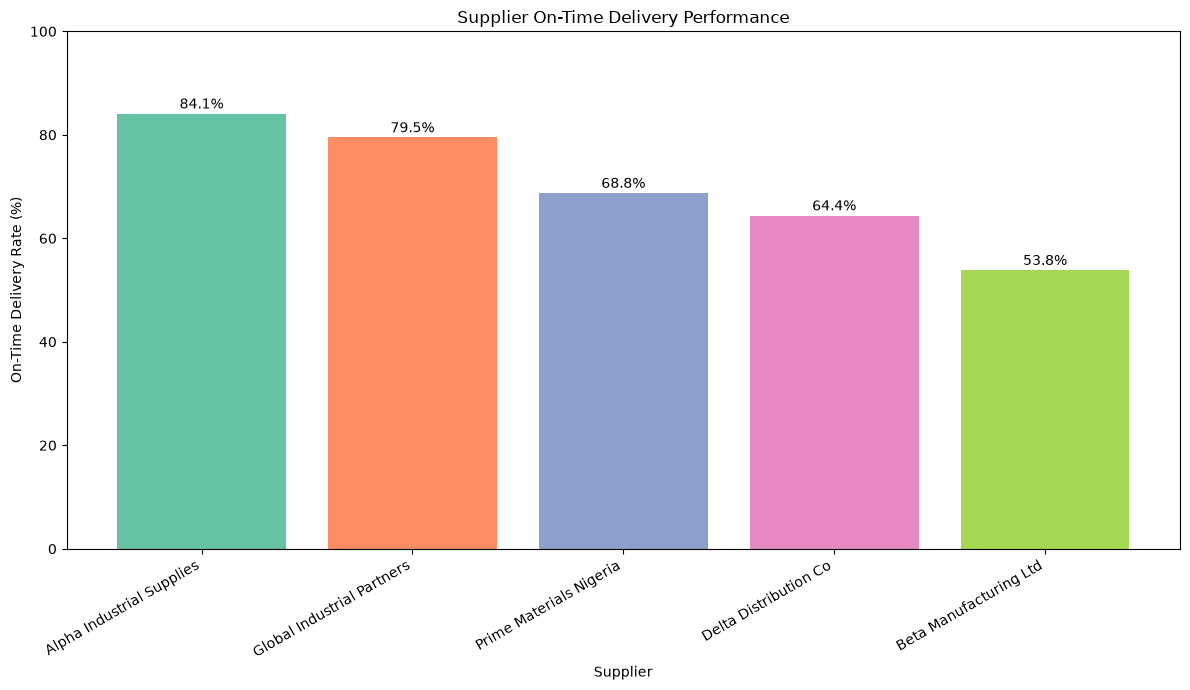

In [7]:
plt.figure(figsize=(12, 7))

plot_data = supplier_delivery.sort_values(
    "on_time_rate",
    ascending=False
)

colors = sns.color_palette(
    "Set2",
    n_colors=len(plot_data)
)

bars = plt.bar(
    plot_data["supplier_name"],
    plot_data["on_time_rate"] * 100,
    color=colors
)

plt.xlabel("Supplier")
plt.ylabel("On-Time Delivery Rate (%)")
plt.title("Supplier On-Time Delivery Performance")

plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(
    bars,
    plot_data["on_time_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

## 6. Supplier Lead-Time Variability

Average lead time alone does not fully describe supplier reliability. Two suppliers may have similar average lead times but substantially different levels of delivery-time variability.

The **Coefficient of Variation (CV)** is used to compare lead-time variability relative to each supplier's average lead time:

**Lead-Time CV = Lead-Time Standard Deviation ÷ Average Lead Time**

A higher CV indicates greater relative variability and therefore greater uncertainty in replenishment planning.

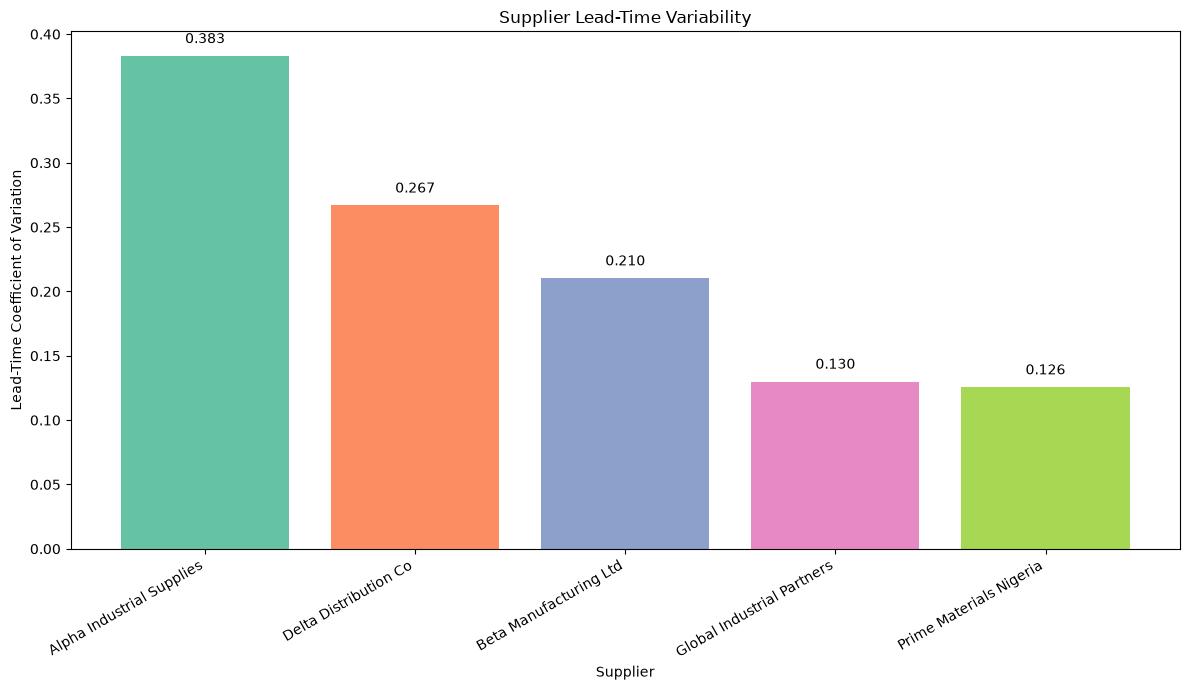

In [8]:
plt.figure(figsize=(12, 7))

plot_data = supplier_lead_time.sort_values(
    "lead_time_cv",
    ascending=False
)

colors = sns.color_palette(
    "Set2",
    n_colors=len(plot_data)
)

bars = plt.bar(
    plot_data["supplier_name"],
    plot_data["lead_time_cv"],
    color=colors
)

plt.xlabel("Supplier")
plt.ylabel("Lead-Time Coefficient of Variation")
plt.title("Supplier Lead-Time Variability")

plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(
    bars,
    plot_data["lead_time_cv"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 7. Supplier Stockout Exposure

Supplier stockout exposure measures the stockout units associated with products supplied by each supplier.

This analysis links supplier information with inventory records to identify suppliers whose product portfolios are associated with greater stockout exposure.

The metric should be interpreted carefully because stockouts can result from multiple factors, including demand variability, replenishment policies, inventory levels, and supplier performance. Therefore, supplier stockout exposure is treated as an indicator rather than direct evidence that a supplier caused the stockouts.

In [10]:
product_supplier = products[
    [
        "product_id",
        "supplier_id",
        "product_name"
    ]
]

supplier_stockout = (
    inventory[
        [
            "product_id",
            "stockout_units"
        ]
    ]
    .merge(
        product_supplier,
        on="product_id",
        how="left"
    )
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(
        stockout_units=("stockout_units", "sum"),
        products_with_stockouts=("product_id", "nunique")
    )
    .merge(
        suppliers[
            [
                "supplier_id",
                "supplier_name",
                "category"
            ]
        ],
        on="supplier_id",
        how="left"
    )
    .sort_values(
        "stockout_units",
        ascending=False
    )
    .reset_index(drop=True)
)

display(supplier_stockout)

,supplier_id,stockout_units,products_with_stockouts,supplier_name,category
0,SUP001,9363,5,Alpha Industrial Supplies,Packaging
1,SUP003,4858,6,Delta Distribution Co,Components
2,SUP004,2463,3,Prime Materials Nigeria,Chemicals
3,SUP005,908,4,Global Industrial Partners,Industrial Equipment
4,SUP002,648,2,Beta Manufacturing Ltd,Raw Materials


## 8. Supplier Stockout Rate

Supplier stockout rate measures stockout units relative to total demand for the products supplied by each supplier.

**Stockout Rate = Total Stockout Units ÷ Total Demand**

This provides a normalized measure that allows suppliers with different product portfolios and demand volumes to be compared more consistently.

The metric should be interpreted alongside supplier lead time, delivery reliability, demand variability, and procurement exposure.

In [11]:
supplier_product_map = products[
    [
        "product_id",
        "supplier_id"
    ]
]

supplier_stockout_rate = (
    inventory[
        [
            "product_id",
            "demand",
            "stockout_units"
        ]
    ]
    .merge(
        supplier_product_map,
        on="product_id",
        how="left"
    )
    .groupby(
        "supplier_id",
        as_index=False
    )
    .agg(
        total_demand=("demand", "sum"),
        stockout_units=("stockout_units", "sum")
    )
)

supplier_stockout_rate["stockout_rate"] = (
    supplier_stockout_rate["stockout_units"]
    / supplier_stockout_rate["total_demand"]
)

supplier_stockout_rate = (
    supplier_stockout_rate
    .merge(
        suppliers[
            [
                "supplier_id",
                "supplier_name",
                "category"
            ]
        ],
        on="supplier_id",
        how="left"
    )
    .sort_values(
        "stockout_rate",
        ascending=False
    )
    .reset_index(drop=True)
)

display(supplier_stockout_rate)

,supplier_id,total_demand,stockout_units,stockout_rate,supplier_name,category
0,SUP003,71089,4858,0.068337,Delta Distribution Co,Components
1,SUP004,37175,2463,0.066254,Prime Materials Nigeria,Chemicals
2,SUP001,144951,9363,0.064594,Alpha Industrial Supplies,Packaging
3,SUP005,14335,908,0.063341,Global Industrial Partners,Industrial Equipment
4,SUP002,14353,648,0.045147,Beta Manufacturing Ltd,Raw Materials


## 9. Supplier Stockout Rate Visualization

This visualization compares stockout rates across suppliers after normalizing stockout units by total demand.

The chart helps identify differences in inventory-availability exposure across supplier portfolios while accounting for differences in demand volume.

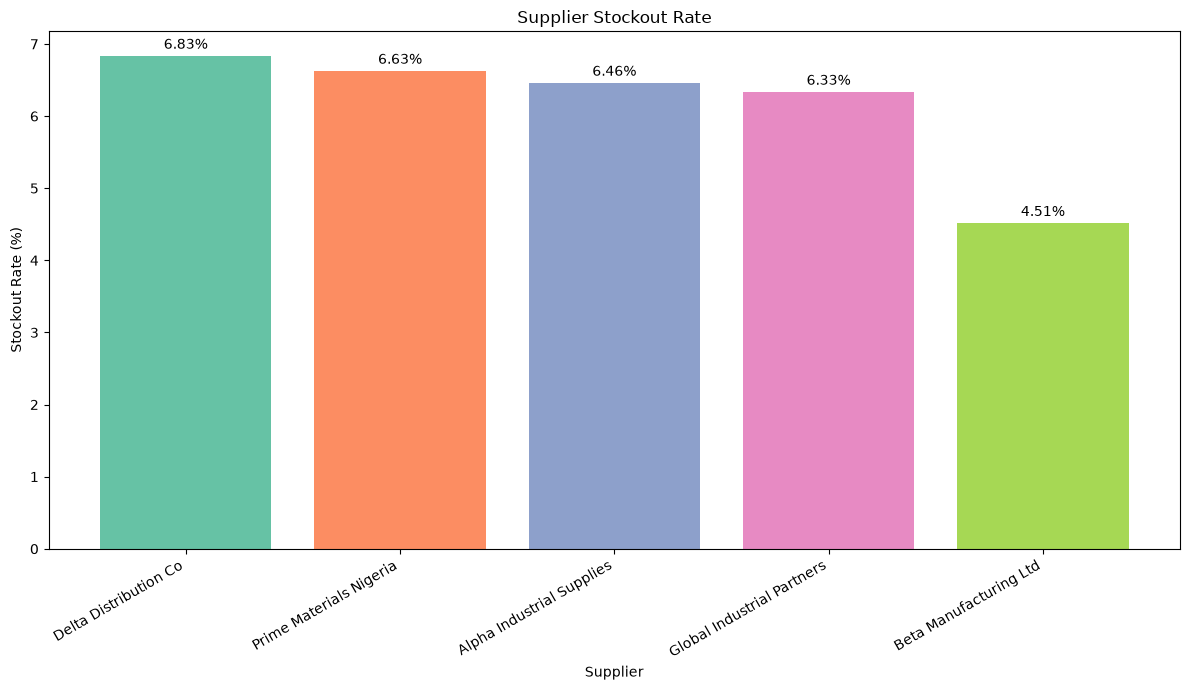

In [12]:
plt.figure(figsize=(12, 7))

plot_data = supplier_stockout_rate.sort_values(
    "stockout_rate",
    ascending=False
)

colors = sns.color_palette(
    "Set2",
    n_colors=len(plot_data)
)

bars = plt.bar(
    plot_data["supplier_name"],
    plot_data["stockout_rate"] * 100,
    color=colors
)

plt.xlabel("Supplier")
plt.ylabel("Stockout Rate (%)")
plt.title("Supplier Stockout Rate")

plt.xticks(
    rotation=30,
    ha="right"
)

for bar, value in zip(
    bars,
    plot_data["stockout_rate"] * 100
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## 10. Consolidated Supplier Performance

This table consolidates the major supplier-performance indicators developed in this notebook.

The summary combines procurement exposure, lead-time performance, delivery reliability, and stockout exposure to provide a single view of supplier performance.

The indicators are intended to support procurement review and supplier-management decisions rather than establish causation between supplier performance and stockouts.

In [13]:
supplier_performance = (
    supplier_summary[
        [
            "supplier_id",
            "supplier_name",
            "category",
            "purchase_orders",
            "products_supplied",
            "total_units_ordered",
            "procurement_spend",
            "spend_share"
        ]
    ]
    .merge(
        supplier_lead_time[
            [
                "supplier_id",
                "average_lead_time_days",
                "minimum_lead_time_days",
                "maximum_lead_time_days",
                "lead_time_std",
                "lead_time_cv"
            ]
        ],
        on="supplier_id",
        how="left"
    )
    .merge(
        supplier_delivery[
            [
                "supplier_id",
                "on_time_rate",
                "late_rate"
            ]
        ],
        on="supplier_id",
        how="left"
    )
    .merge(
        supplier_stockout_rate[
            [
                "supplier_id",
                "total_demand",
                "stockout_units",
                "stockout_rate"
            ]
        ],
        on="supplier_id",
        how="left"
    )
)

supplier_performance = supplier_performance.sort_values(
    "procurement_spend",
    ascending=False
).reset_index(drop=True)

display(supplier_performance)

,supplier_id,supplier_name,category,purchase_orders,products_supplied,total_units_ordered,procurement_spend,spend_share,average_lead_time_days,minimum_lead_time_days,maximum_lead_time_days,lead_time_std,lead_time_cv,on_time_rate,late_rate,total_demand,stockout_units,stockout_rate
0,SUP005,Global Industrial Partners,Industrial Equipment,39,4,18148,3465645000,0.570567,16.974359,13,22,2.206297,0.129978,0.794872,0.205128,14335,908,0.063341
1,SUP003,Delta Distribution Co,Components,59,6,32205,1143488500,0.188258,10.796610,4,18,2.881449,0.266885,0.644068,0.355932,71089,4858,0.068337
2,SUP002,Beta Manufacturing Ltd,Raw Materials,26,2,14239,992040000,0.163325,14.269231,7,20,3.000769,0.210296,0.538462,0.461538,14353,648,0.045147
3,SUP004,Prime Materials Nigeria,Chemicals,32,3,17162,291186000,0.047939,20.968750,17,26,2.633339,0.125584,0.687500,0.312500,37175,2463,0.066254
4,SUP001,Alpha Industrial Supplies,Packaging,44,5,26291,181678100,0.029911,6.863636,0,13,2.628917,0.383021,0.840909,0.159091,144951,9363,0.064594


## 11. Supplier Risk Indicators

This analysis combines several supplier-performance indicators to identify areas requiring closer procurement attention.

The screening indicators are:

- **High Spend Exposure:** Procurement spend share ≥ 15%.
- **Long Lead Time:** Average lead time above the supplier portfolio median.
- **High Lead-Time Variability:** Lead-time CV above the supplier portfolio median.
- **Low On-Time Delivery:** On-time delivery rate below the supplier portfolio median.
- **High Stockout Rate:** Stockout rate above the supplier portfolio median.

Each indicator is binary and represents a screening condition.

The resulting indicator count is **not a formal probability of supplier failure or a supplier ranking**. It is a transparent analytical tool for identifying suppliers that warrant further review.

In [14]:
supplier_risk = supplier_performance.copy()

lead_time_median = (
    supplier_risk["average_lead_time_days"].median()
)

lead_time_cv_median = (
    supplier_risk["lead_time_cv"].median()
)

on_time_median = (
    supplier_risk["on_time_rate"].median()
)

stockout_rate_median = (
    supplier_risk["stockout_rate"].median()
)

supplier_risk["high_spend_exposure"] = (
    supplier_risk["spend_share"] >= 0.15
)

supplier_risk["long_lead_time"] = (
    supplier_risk["average_lead_time_days"]
    > lead_time_median
)

supplier_risk["high_lead_time_variability"] = (
    supplier_risk["lead_time_cv"]
    > lead_time_cv_median
)

supplier_risk["low_on_time_delivery"] = (
    supplier_risk["on_time_rate"]
    < on_time_median
)

supplier_risk["high_stockout_rate"] = (
    supplier_risk["stockout_rate"]
    > stockout_rate_median
)

supplier_risk["risk_indicators"] = (
    supplier_risk["high_spend_exposure"].astype(int)
    + supplier_risk["long_lead_time"].astype(int)
    + supplier_risk["high_lead_time_variability"].astype(int)
    + supplier_risk["low_on_time_delivery"].astype(int)
    + supplier_risk["high_stockout_rate"].astype(int)
)

supplier_risk = supplier_risk.sort_values(
    "risk_indicators",
    ascending=False
).reset_index(drop=True)

display(
    supplier_risk[
        [
            "supplier_id",
            "supplier_name",
            "spend_share",
            "average_lead_time_days",
            "lead_time_cv",
            "on_time_rate",
            "stockout_rate",
            "high_spend_exposure",
            "long_lead_time",
            "high_lead_time_variability",
            "low_on_time_delivery",
            "high_stockout_rate",
            "risk_indicators"
        ]
    ]
)

,supplier_id,supplier_name,spend_share,average_lead_time_days,lead_time_cv,on_time_rate,stockout_rate,high_spend_exposure,long_lead_time,high_lead_time_variability,low_on_time_delivery,high_stockout_rate,risk_indicators
0,SUP003,Delta Distribution Co,0.188258,10.796610,0.266885,0.644068,0.068337,True,False,True,True,True,4
1,SUP005,Global Industrial Partners,0.570567,16.974359,0.129978,0.794872,0.063341,True,True,False,False,False,2
2,SUP002,Beta Manufacturing Ltd,0.163325,14.269231,0.210296,0.538462,0.045147,True,False,False,True,False,2
3,SUP004,Prime Materials Nigeria,0.047939,20.968750,0.125584,0.687500,0.066254,False,True,False,False,True,2
4,SUP001,Alpha Industrial Supplies,0.029911,6.863636,0.383021,0.840909,0.064594,False,False,True,False,False,1


## 12. Supplier Risk Indicator Visualization

This visualization shows the number of supplier-performance screening indicators triggered for each supplier.

The indicators consider procurement exposure, lead time, lead-time variability, delivery reliability, and stockout rate.

A higher indicator count means that more screening conditions were triggered and therefore the supplier may warrant closer procurement or supplier-performance review.

The indicator count is not a formal supplier-risk score or probability of failure.

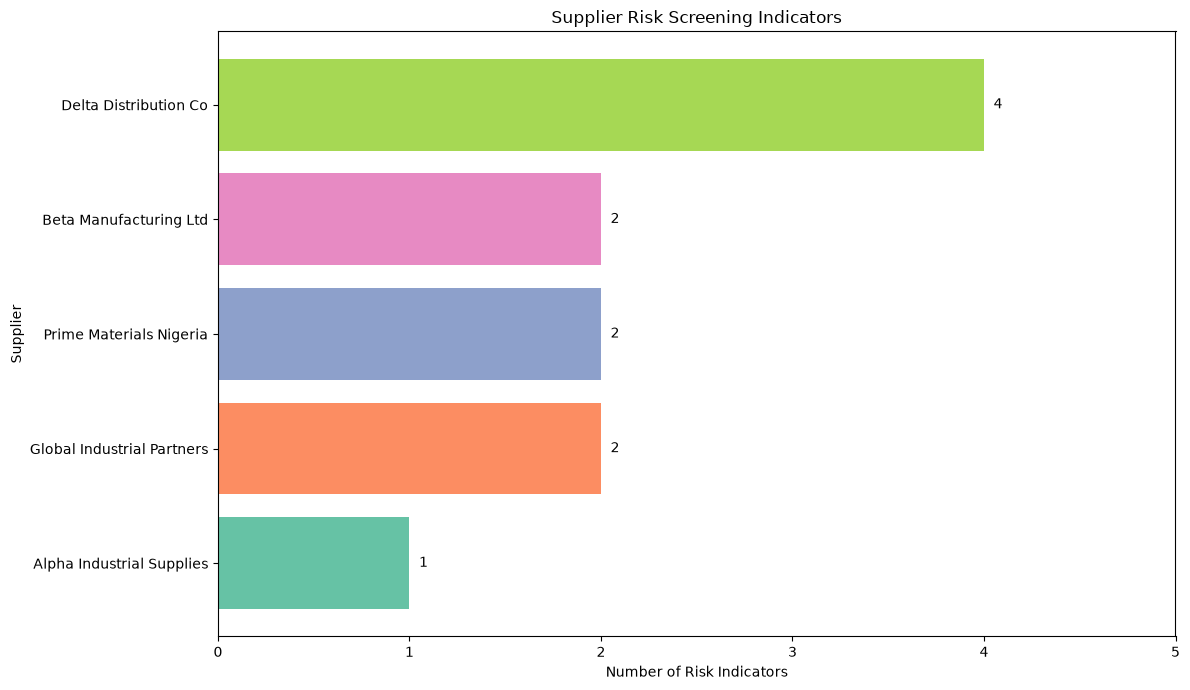

In [15]:
plt.figure(figsize=(12, 7))

plot_data = supplier_risk.sort_values(
    "risk_indicators",
    ascending=True
)

colors = sns.color_palette(
    "Set2",
    n_colors=len(plot_data)
)

bars = plt.barh(
    plot_data["supplier_name"],
    plot_data["risk_indicators"],
    color=colors
)

plt.xlabel("Number of Risk Indicators")
plt.ylabel("Supplier")
plt.title("Supplier Risk Screening Indicators")

for bar, value in zip(
    bars,
    plot_data["risk_indicators"]
):
    plt.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value}",
        va="center"
    )

plt.xticks(
    range(
        0,
        int(plot_data["risk_indicators"].max()) + 2
    )
)

plt.tight_layout()
plt.show()

## 13. Supplier Risk Indicator Breakdown

This analysis examines the individual screening conditions contributing to each supplier's indicator count.

The breakdown helps distinguish whether supplier attention is associated with:

- Procurement spend exposure
- Long lead time
- High lead-time variability
- Low on-time delivery
- High stockout rate

These indicators should be interpreted together with the underlying supplier and inventory metrics rather than as a formal supplier ranking.

In [16]:
risk_breakdown = supplier_risk[
    [
        "supplier_name",
        "high_spend_exposure",
        "long_lead_time",
        "high_lead_time_variability",
        "low_on_time_delivery",
        "high_stockout_rate"
    ]
].copy()

risk_breakdown = risk_breakdown.set_index(
    "supplier_name"
)

risk_breakdown = risk_breakdown.astype(int)

display(risk_breakdown)

,high_spend_exposure,long_lead_time,high_lead_time_variability,low_on_time_delivery,high_stockout_rate
supplier_name,,,,,
Delta Distribution Co,1,0,1,1,1
Global Industrial Partners,1,1,0,0,0
Beta Manufacturing Ltd,1,0,0,1,0
Prime Materials Nigeria,0,1,0,0,1
Alpha Industrial Supplies,0,0,1,0,0


In [17]:
risk_breakdown = supplier_risk[
    [
        "supplier_name",
        "high_spend_exposure",
        "long_lead_time",
        "high_lead_time_variability",
        "low_on_time_delivery",
        "high_stockout_rate"
    ]
].copy()

risk_breakdown = risk_breakdown.set_index(
    "supplier_name"
)

risk_breakdown = risk_breakdown.astype(int)

display(risk_breakdown)

,high_spend_exposure,long_lead_time,high_lead_time_variability,low_on_time_delivery,high_stockout_rate
supplier_name,,,,,
Delta Distribution Co,1,0,1,1,1
Global Industrial Partners,1,1,0,0,0
Beta Manufacturing Ltd,1,0,0,1,0
Prime Materials Nigeria,0,1,0,0,1
Alpha Industrial Supplies,0,0,1,0,0


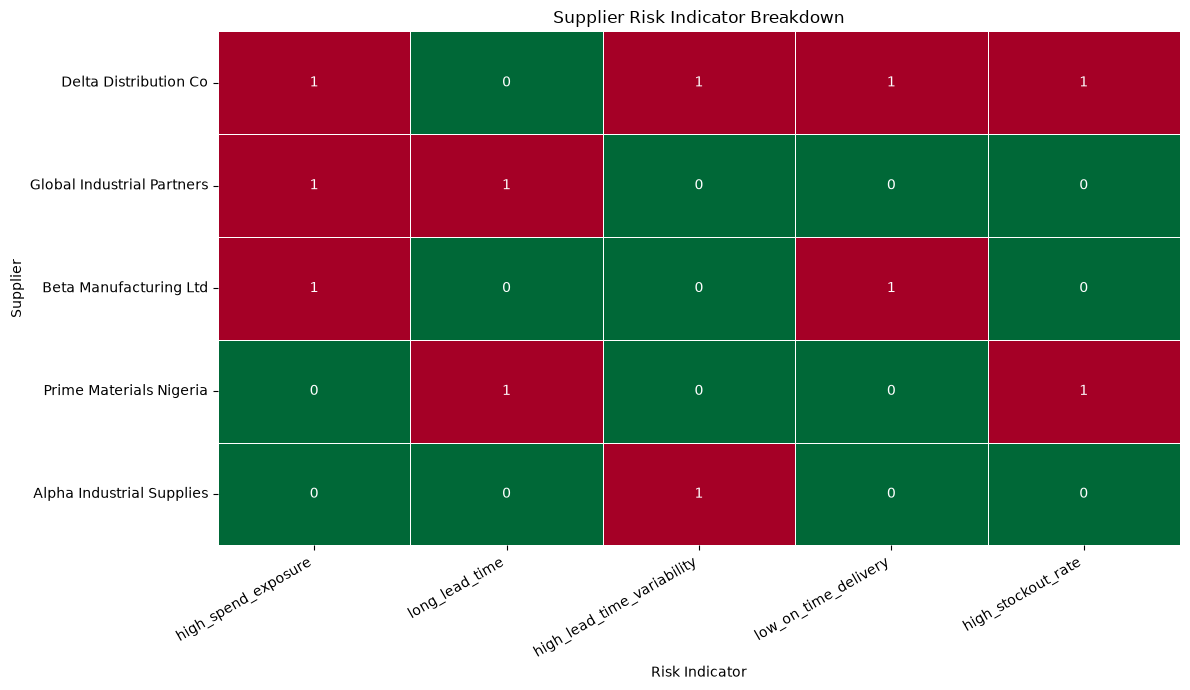

In [18]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    risk_breakdown,
    annot=True,
    fmt="d",
    cmap="RdYlGn_r",
    linewidths=0.5,
    cbar=False
)

plt.xlabel("Risk Indicator")
plt.ylabel("Supplier")
plt.title("Supplier Risk Indicator Breakdown")

plt.xticks(
    rotation=30,
    ha="right"
)

plt.tight_layout()
plt.show()

## 14. Supplier Performance vs Procurement Exposure

This analysis compares supplier procurement spend with on-time delivery performance.

The objective is to identify suppliers where procurement exposure and delivery performance should be considered together when planning supplier-management actions.

The analysis does not determine a preferred supplier. It provides evidence for procurement review and supplier relationship management.

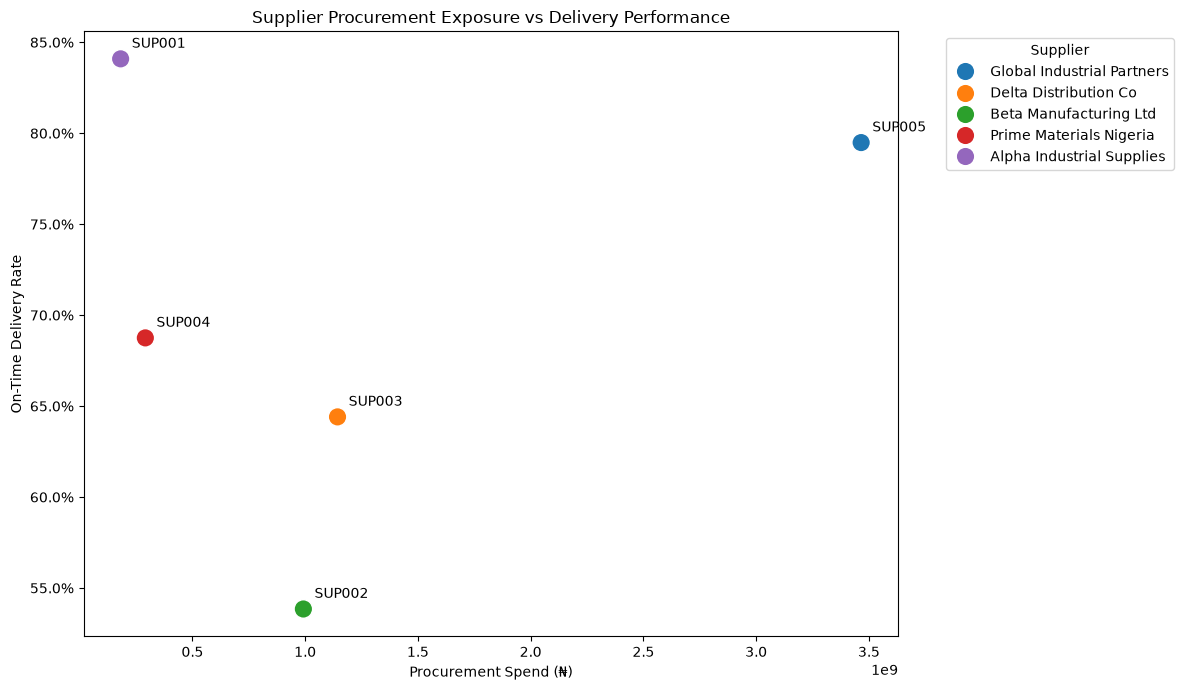

In [19]:
plt.figure(figsize=(12, 7))

plot_data = supplier_performance.copy()

sns.scatterplot(
    data=plot_data,
    x="procurement_spend",
    y="on_time_rate",
    hue="supplier_name",
    s=180
)

for _, row in plot_data.iterrows():
    plt.annotate(
        row["supplier_id"],
        (
            row["procurement_spend"],
            row["on_time_rate"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Procurement Spend (₦)")
plt.ylabel("On-Time Delivery Rate")
plt.title("Supplier Procurement Exposure vs Delivery Performance")

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.legend(
    title="Supplier",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 15. Supplier Lead-Time vs Delivery Reliability

This analysis compares average supplier lead time with on-time delivery performance.

The visualization helps identify suppliers where replenishment duration and delivery reliability should be considered together when designing procurement and inventory policies.

The relationship should be interpreted descriptively because the dataset contains only five suppliers and does not establish causation.

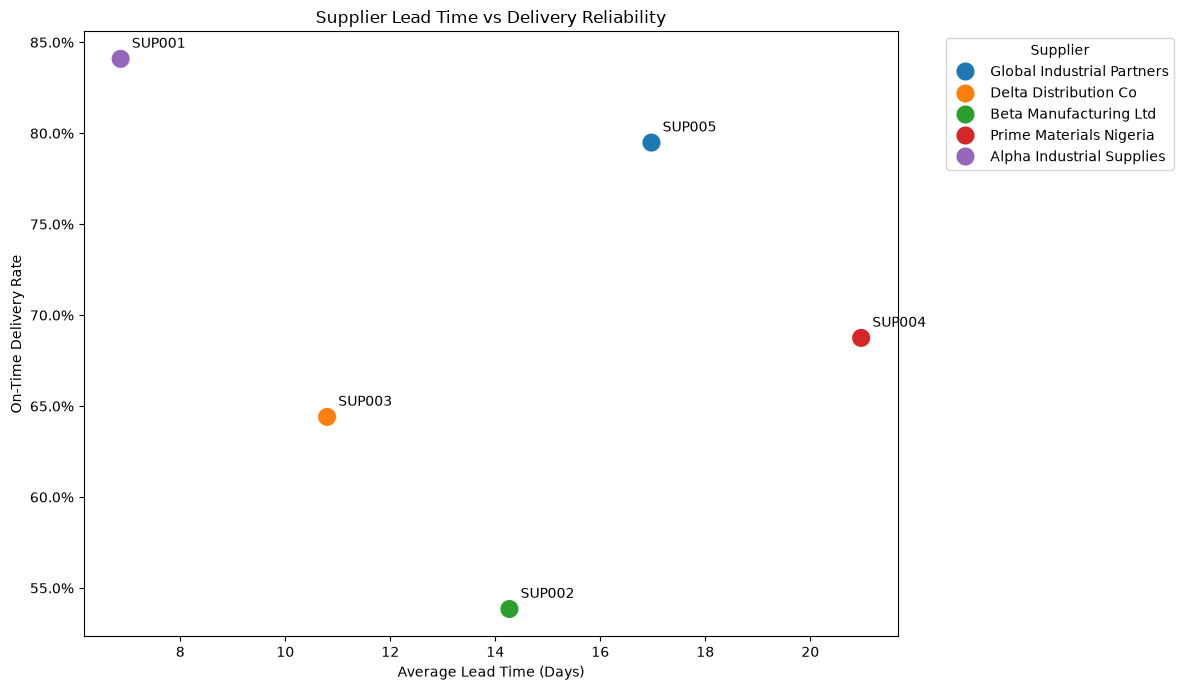

In [20]:
plt.figure(figsize=(12, 7))

plot_data = supplier_performance.copy()

sns.scatterplot(
    data=plot_data,
    x="average_lead_time_days",
    y="on_time_rate",
    hue="supplier_name",
    s=200
)

for _, row in plot_data.iterrows():
    plt.annotate(
        row["supplier_id"],
        (
            row["average_lead_time_days"],
            row["on_time_rate"]
        ),
        xytext=(8, 8),
        textcoords="offset points"
    )

plt.xlabel("Average Lead Time (Days)")
plt.ylabel("On-Time Delivery Rate")
plt.title("Supplier Lead Time vs Delivery Reliability")

plt.gca().yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.legend(
    title="Supplier",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 16. Supplier Business Insights

The supplier analysis identifies several procurement and supply-chain management considerations.

### 1. Procurement spend concentration

SUP005 accounts for approximately **57.1% of total procurement spend**. This creates significant financial exposure to a single supplier and supports the need for close monitoring of supplier continuity and procurement concentration.

### 2. Delivery reliability varies across suppliers

Supplier on-time delivery performance ranges from approximately **53.8% to 84.1%**.

SUP002 has the lowest on-time delivery rate at approximately **53.8%**, while SUP001 records the highest at approximately **84.1%**.

This variation indicates that supplier delivery reliability should be incorporated into procurement and replenishment planning.

### 3. Lead-time differences affect replenishment planning

Average supplier lead time ranges from approximately **6.9 to 21.0 days**.

SUP004 has the longest average lead time, while SUP001 has the shortest. These differences should be reflected in reorder-point and safety-stock calculations rather than applying a single lead-time assumption across all suppliers.

### 4. Lead-time variability is an additional planning consideration

SUP001 has the highest lead-time coefficient of variation at approximately **0.383**, while SUP004 has the lowest at approximately **0.126**.

High relative variability can make replenishment timing less predictable and may require closer monitoring of purchase-order timing and inventory buffers.

### 5. Supplier-associated stockout exposure

SUP001-associated products account for **9,363 stockout units**, the largest supplier-associated stockout volume.

This does not establish that SUP001 caused the stockouts. Stockout exposure can also be influenced by demand variability, inventory policy, replenishment timing, and product-level demand patterns.

### 6. Stockout rates differ across supplier portfolios

Supplier-associated stockout rates range from approximately **4.5% to 6.8%**.

SUP003 has the highest stockout rate at approximately **6.83%**, while SUP002 has the lowest at approximately **4.51%**.

These rates should be examined alongside demand volume, lead time, delivery reliability, and inventory policy.

### 7. Procurement risk should be monitored using multiple indicators

The supplier risk-screening framework combines:

- Procurement spend exposure
- Average lead time
- Lead-time variability
- On-time delivery
- Stockout rate

Using multiple indicators provides a more transparent view of supplier-performance conditions than relying on a single metric.

### Management Implications

Based on the analysis, procurement teams should consider:

- Monitoring suppliers with high procurement-spend exposure.
- Incorporating supplier-specific lead times into replenishment calculations.
- Monitoring suppliers with high lead-time variability.
- Investigating persistent late deliveries through supplier performance reviews.
- Reviewing products associated with elevated stockout exposure.
- Considering supplier diversification where procurement concentration creates material business exposure.
- Linking supplier performance data with inventory and demand-planning decisions.
- Establishing regular supplier-performance dashboards using lead time, OTIF/on-time delivery, stockout exposure, spend, and purchase-order metrics.

These findings provide analytical evidence for procurement review and supplier relationship management rather than definitive conclusions about supplier quality or causation.

In [21]:
supplier_management_summary = supplier_performance[
    [
        "supplier_id",
        "supplier_name",
        "category",
        "purchase_orders",
        "procurement_spend",
        "spend_share",
        "average_lead_time_days",
        "lead_time_cv",
        "on_time_rate",
        "stockout_rate"
    ]
].copy()

supplier_management_summary["spend_share"] = (
    supplier_management_summary["spend_share"] * 100
)

supplier_management_summary["on_time_rate"] = (
    supplier_management_summary["on_time_rate"] * 100
)

supplier_management_summary["stockout_rate"] = (
    supplier_management_summary["stockout_rate"] * 100
)

supplier_management_summary = supplier_management_summary.rename(
    columns={
        "supplier_id": "Supplier ID",
        "supplier_name": "Supplier",
        "category": "Category",
        "purchase_orders": "PO Count",
        "procurement_spend": "Procurement Spend",
        "spend_share": "Spend Share (%)",
        "average_lead_time_days": "Avg Lead Time (Days)",
        "lead_time_cv": "Lead Time CV",
        "on_time_rate": "On-Time Delivery (%)",
        "stockout_rate": "Stockout Rate (%)"
    }
)

display(
    supplier_management_summary.style.format(
        {
            "Procurement Spend": "₦{:,.0f}",
            "Spend Share (%)": "{:.1f}%",
            "Avg Lead Time (Days)": "{:.1f}",
            "Lead Time CV": "{:.3f}",
            "On-Time Delivery (%)": "{:.1f}%",
            "Stockout Rate (%)": "{:.2f}%"
        }
    )
)

,Supplier ID,Supplier,Category,PO Count,Procurement Spend,Spend Share (%),Avg Lead Time (Days),Lead Time CV,On-Time Delivery (%),Stockout Rate (%)
0,SUP005,Global Industrial Partners,Industrial Equipment,39,"₦3,465,645,000",57.1%,17.0,0.130,79.5%,6.33%
1,SUP003,Delta Distribution Co,Components,59,"₦1,143,488,500",18.8%,10.8,0.267,64.4%,6.83%
2,SUP002,Beta Manufacturing Ltd,Raw Materials,26,"₦992,040,000",16.3%,14.3,0.210,53.8%,4.51%
3,SUP004,Prime Materials Nigeria,Chemicals,32,"₦291,186,000",4.8%,21.0,0.126,68.8%,6.63%
4,SUP001,Alpha Industrial Supplies,Packaging,44,"₦181,678,100",3.0%,6.9,0.383,84.1%,6.46%
